In [2]:
import glob
import json
import re

In [3]:
import glob
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")

path_list = [
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft'
]

data_records = []

for path in path_list:
    model_name = path.split('/')[-2]  # 경로에서 모델 이름 추출 (예: meta-llama...)
    print(f"Processing: {model_name}")
    
    # json 파일 검색
    json_files = glob.glob(f'{path}/*.json')
    json_files = [f for f in json_files if 'zeroshot' not in f] # zeroshot 제외
    
    for file_path in json_files:
        filename = os.path.basename(file_path)
        
        try:
            with open(file_path, 'r') as f:
                content = json.load(f)
                
                # JSON 내의 모든 키를 순회하며 .pt로 끝나는 레이어 정보 추출
                for key, val in content.items():
                    if key.endswith('.pt'):
                        # 필요한 정보 추출
                        record = {
                            'filename': filename,
                            'layer': key,  # 예: 0_q.pt
                            'module': key.split('_')[1].replace('.pt', ''), # 예: q, k, v ...
                            'layer_idx': int(key.split('_')[0]), # 예: 0, 1 ...
                            'bpp_loss': val.get('bpp_loss'),
                            'proxy_err': val.get('proxy_err'),
                            'mse': val.get('mse')
                        }
                        data_records.append(record)
                        
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# DataFrame 생성
df = pd.DataFrame(data_records)

# 데이터 확인
print(f"Total records: {len(df)}")
print(df.head())

Processing: meta-llama--Meta-Llama-3-8B
Total records: 2912
                filename    layer module  layer_idx  bpp_loss  proxy_err  \
0  lmbda300_mse_col.json   0_q.pt      q          0  3.896632   0.000029   
1  lmbda300_mse_col.json   0_k.pt      k          0  3.899825   0.000044   
2  lmbda300_mse_col.json   0_v.pt      v          0  3.848691   0.004062   
3  lmbda300_mse_col.json   0_o.pt      o          0  3.932431   0.000773   
4  lmbda300_mse_col.json  0_up.pt     up          0  3.953287   0.002990   

            mse  
0  3.897216e-06  
1  7.895388e-06  
2  4.816749e-07  
3  4.773064e-07  
4  8.922190e-07  


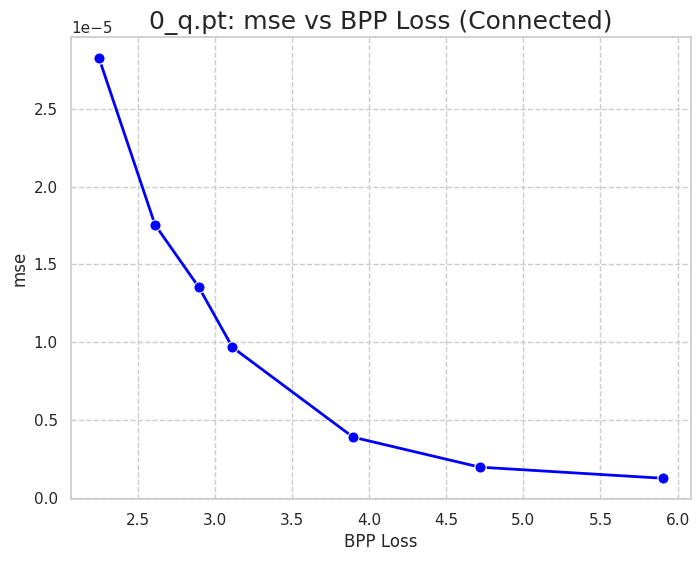

In [7]:
def plot_layer_connected(dataframe, layer_name, y_axis='proxy_err'):
    """
    단일 레이어에 대해 점을 찍고, 그 점들을 잇는 선을 그립니다.
    """
    subset = dataframe[dataframe['layer'] == layer_name].copy()
    
    if subset.empty:
        print(f"No data found for layer: {layer_name}")
        return

    # 선이 꼬이지 않도록 X축(bpp_loss) 기준으로 정렬 필수
    subset = subset.sort_values(by='bpp_loss')

    plt.figure(figsize=(8, 6))
    
    # lineplot: 점을 잇는 선 (marker='o'를 주면 점도 같이 찍힘)
    sns.lineplot(
        data=subset, 
        x='bpp_loss', 
        y=y_axis,
        marker='o',       # 데이터 포인트 표시
        markersize=8,     # 점 크기
        color='blue',     # 색상
        linewidth=2,      # 선 굵기
        sort=True         # X축 기준 자동 정렬 (명시적)
    )
    
    plt.rcParams['font.size'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 23
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 20
    plt.rcParams['figure.titlesize'] = 20
    
    plt.title(f'{layer_name}: {y_axis} vs BPP Loss (Connected)')
    plt.xlabel('BPP Loss')
    plt.ylabel(y_axis)
    plt.grid(True, ls="--")
    plt.show()

plot_layer_connected(df, '0_q.pt', y_axis='mse')


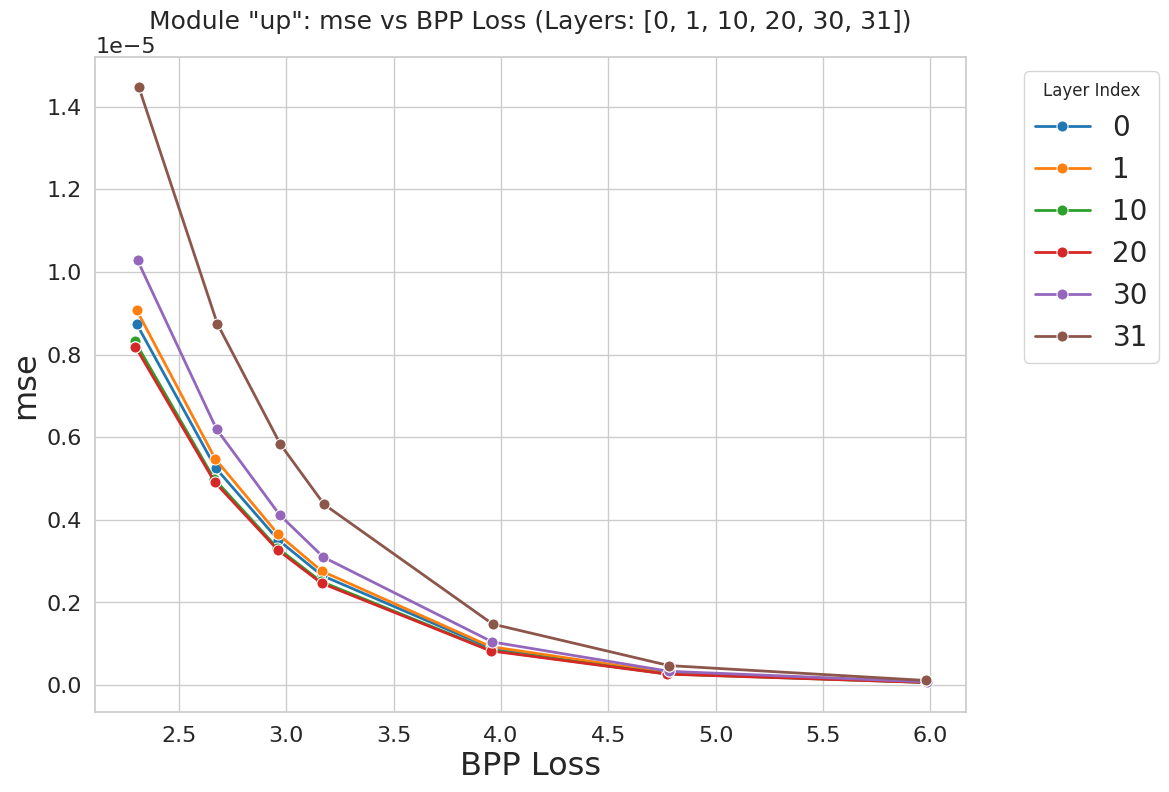

In [8]:
def plot_module_connected_filtered(dataframe, module_type, y_axis='proxy_err', target_layers=None):
    """
    특정 레이어(target_layers)만 골라서 점과 선을 그립니다.
    """
    # 1. 모듈 타입으로 필터링
    subset = dataframe[dataframe['module'] == module_type].copy()
    
    # 2. [추가됨] 특정 레이어 번호만 필터링 (target_layers가 입력된 경우)
    if target_layers is not None:
        subset = subset[subset['layer_idx'].isin(target_layers)]
    
    # 3. 정렬 (선이 꼬이지 않게 하기 위함)
    subset = subset.sort_values(by=['layer_idx', 'bpp_loss'])

    plt.figure(figsize=(12, 8))
    
    # 4. 그래프 그리기
    # 레이어 개수가 줄어들었으므로 palette를 'tab10'이나 'Set2' 같이 구분 잘 되는 것으로 변경해도 좋습니다.
    sns.lineplot(
        data=subset,
        x='bpp_loss',
        y=y_axis,
        hue='layer_idx',    # 레이어별 색상 구분
        palette='tab10',    # 색상 테마 (레이어 수가 적을 땐 tab10 추천)
        marker='o',         # 점 표시
        dashes=False,       # 모든 선을 실선으로
        markersize=8,
        linewidth=2
    )
    
    plt.title(f'Module "{module_type}": {y_axis} vs BPP Loss (Layers: {target_layers})')
    plt.xlabel('BPP Loss')
    plt.ylabel(y_axis)
    
    # 범례에 레이어 번호가 정수형으로 깔끔하게 나오도록 설정
    plt.legend(title='Layer Index', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# === 실행 예시 ===
# 0, 1, 10, 20, 31번 레이어만 선택하여 그리기
plot_module_connected_filtered(
    df, 
    'up', 
    y_axis='mse', 
    target_layers=[0, 1, 10, 20, 30, 31]
)

In [ ]:
import glob
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. 데이터 로드 및 통합
# ---------------------------------------------------------
data_records = []

# A. Lambda 데이터 경로 (기존)
lambda_path_list = [
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft'
]

for path in lambda_path_list:
    if not os.path.exists(path): continue
    print(f"Processing Lambda: {path}")
    
    json_files = glob.glob(f'{path}/*.json')
    json_files = [f for f in json_files if 'zeroshot' not in f]
    
    for file_path in json_files:
        filename = os.path.basename(file_path)
        try:
            with open(file_path, 'r') as f:
                content = json.load(f)
                for key, val in content.items():
                    if key.endswith('.pt'):
                        record = {
                            'layer': key,
                            'module': key.split('_')[1].replace('.pt', ''),
                            'layer_idx': int(key.split('_')[0]),
                            'bpp_loss': val.get('bpp_loss'),
                            'proxy_err': val.get('proxy_err'),
                            'mse': val.get('mse'),
                            'source': 'NWC'  # 소스 구분
                        }
                        data_records.append(record)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# B. QTiP 데이터 경로 (추가)
# 예: 2bit_MSE.json, 4bit_MSE.json 등이 있는 폴더 경로를 지정하세요.
qtip_path_list = [
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/qtip/llama3_8b/ft1' 
]

for path in qtip_path_list:
    if not os.path.exists(path): continue
    print(f"Processing QTiP: {path}")
    
    # {}bit_MSE.json 패턴 검색 (예: 2bit_MSE.json)
    json_files = glob.glob(f'{path}/*bit_MSE_data.json')
    
    for file_path in json_files:
        filename = os.path.basename(file_path)
        
        # 파일명에서 비트 수 추출 (예: "2bit_MSE.json" -> 2.0)
        try:
            # 'bit' 문자열 앞의 숫자를 추출
            bit_rate = float(filename.split('bit')[0])
        except:
            print(f"Skipping {filename}: Cannot extract bit rate")
            continue
            
        try:
            with open(file_path, 'r') as f:
                content = json.load(f)
                for key, val in content.items():
                    if key.endswith('.pt'):
                        record = {
                            'layer': key,
                            'module': key.split('_')[1].replace('.pt', ''),
                            'layer_idx': int(key.split('_')[0]),
                            'bpp_loss': bit_rate,  # QTiP은 비트 수를 BPP로 사용
                            'proxy_err': val.get('proxy_err'),     # QTiP엔 proxy_err 정보 없음
                            'mse': val.get('mse'),
                            'source': 'QTIP'       # 소스 구분
                        }
                        data_records.append(record)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# DataFrame 생성
df = pd.DataFrame(data_records)

# ---------------------------------------------------------
# 2. 비교 그래프 그리기 (Lambda vs QTiP)
# ---------------------------------------------------------

def plot_comparison(dataframe, module_type, y_axis='mse', target_layers=None):
    """
    Lambda 결과와 QTiP 결과를 함께 비교하여 그립니다.
    Lambda: 실선 (Solid)
    QTiP: 점선 (Dashed) 및 다른 마커
    """
    # 1. 모듈 필터링
    subset = dataframe[dataframe['module'] == module_type].copy()
    
    # 2. 레이어 필터링
    if target_layers is not None:
        subset = subset[subset['layer_idx'].isin(target_layers)]
    
    # 3. 정렬 (선 그래프를 위해 X축 기준 정렬 필수)
    subset = subset.sort_values(by=['layer_idx', 'bpp_loss'])

    plt.figure(figsize=(12, 8))
    
    # 4. 그래프 그리기
    # style='source' : Lambda와 QTiP의 선 스타일(실선/점선)과 마커를 다르게 함
    sns.lineplot(
        data=subset,
        x='bpp_loss',
        y=y_axis,
        hue='layer_idx',    # 색상은 레이어별로 구분
        style='source',     # 스타일은 소스별로 구분 (Lambda vs QTiP)
        palette='tab10',    # 색상 테마
        markers=True,       # 데이터 포인트에 마커 표시
        dashes={'NWC': (1, 0), 'QTIP': (2, 2)}, # 실선 vs 점선
        markersize=9,
        linewidth=2
    )
    
    plt.title(f'Module "{module_type}": {y_axis.upper()} vs BPP (Lambda vs QTiP)')
    plt.xlabel('BPP (Bits per Pixel / Loss)')
    plt.ylabel(y_axis.upper())
    
    # 범례 위치 조정
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.grid(True, ls="--", alpha=0.6)
    plt.show()

# === 실행 예시 ===
# 0, 1, 10, 20, 31번 레이어의 'q' 모듈에 대해 MSE 비교
plot_comparison(
    df, 
    'q', 
    y_axis='mse', 
    target_layers=[0, 1, 10, 20, 31]
)

Processing Lambda: /home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft
Processing QTiP: /home/jgryu/workspace/weight_compression/hf_model_comp_results/qtip/llama3_8b/ft1


ValueError: These `dashes` levels are missing values: {'QTIP', 'NWC'}

<Figure size 1200x800 with 0 Axes>

In [15]:
import matplotlib.ticker as ticker

def save_all_layer_comparisons(dataframe, base_dir='./plot', y_axis='mse'):
    """
    모든 레이어에 대해 Lambda vs QTiP 비교 플롯을 생성하고 저장합니다.
    저장 경로: ./plot/{module_type}/{layer_idx}_{module_type}.png
    """
    
    # 1. 데이터프레임에 존재하는 모든 고유한 (module, layer_idx) 조합 추출
    unique_layers = dataframe[['module', 'layer_idx']].drop_duplicates().sort_values(by=['module', 'layer_idx'])
    
    print(f"총 {len(unique_layers)}개의 레이어에 대한 플롯 생성을 시작합니다...")

    for index, row in unique_layers.iterrows():
        module_type = row['module']
        if module_type != 'k': continue
        layer_idx = row['layer_idx']
        layer_name = f"{layer_idx}_{module_type}" # 예: 0_q
        
        # 2. 저장할 디렉토리 생성 (./plot/q, ./plot/k 등)
        save_dir = os.path.join(base_dir, module_type)
        os.makedirs(save_dir, exist_ok=True)
        
        # 3. 해당 레이어 데이터만 필터링
        subset = dataframe[
            (dataframe['module'] == module_type) & 
            (dataframe['layer_idx'] == layer_idx)
        ].copy()
        
        # 선 그래프가 꼬이지 않도록 정렬
        subset = subset.sort_values(by='bpp_loss')
        
        # 4. 플롯 그리기
        plt.figure(figsize=(8, 6))
        
        plt.rcParams['font.size'] = 16
        plt.rcParams['axes.titlesize'] = 18
        plt.rcParams['axes.labelsize'] = 20
        plt.rcParams['xtick.labelsize'] = 16
        plt.rcParams['ytick.labelsize'] = 16
        # plt.rcParams['legend.fontsize'] = 16
        plt.rcParams['legend.fontsize'] = 20
        plt.rcParams['figure.titlesize'] = 22
        
        sns.lineplot(
            data=subset,
            x='bpp_loss',
            y=y_axis,
            hue='source',    # 소스별(Lambda/QTiP) 색상 구분
            style='source',  # 소스별 선 스타일 구분
            palette='tab10',
            markers=True,
            dashes={'NWC': (1, 0), 'QTIP': (2, 2)}, # 실선 vs 점선
            markersize=9,
            linewidth=2,
            # fmt=".1e",
        )  

        ax = plt.gca()
        formatter = ticker.ScalarFormatter(useOffset=True)
        formatter.set_scientific(True) 
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, labels=labels, title=None)
        
        
        plt.title(f'Layer {layer_name.upper()}', weight='bold')
        plt.xlabel('Bits per parameter')
        plt.ylabel(y_axis.upper())
        plt.grid(True, ls="--", alpha=0.6)
        
        # 5. 파일 저장 및 닫기
        save_path = os.path.join(save_dir, f"{layer_name}.pdf")
        # plt.savefig(save_path)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close() # [중요] 메모리 해제를 위해 반드시 닫아야 함
        
        if index % 10 == 0:
            print(f"Saved: {save_path} (Progress: {index+1}/{len(unique_layers)})")

    print("모든 플롯 저장이 완료되었습니다.")

# === 실행 ===
# df는 이전 단계에서 생성된 데이터프레임이어야 합니다.
save_all_layer_comparisons(df, base_dir='./plot/perlayer_mse', y_axis='mse')

총 224개의 레이어에 대한 플롯 생성을 시작합니다...


Saved: ./plot/perlayer_mse/k/7_k.pdf (Progress: 51/224)
Saved: ./plot/perlayer_mse/k/17_k.pdf (Progress: 121/224)
Saved: ./plot/perlayer_mse/k/27_k.pdf (Progress: 191/224)
모든 플롯 저장이 완료되었습니다.
